In [12]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import matplotlib.pyplot as plt

In [2]:
datasetTrain = os.path.join('datasets', 'PetImages', 'Train')
datasetTest = os.path.join('datasets', 'PetImages', 'Test')

In [3]:
data_genaretor = ImageDataGenerator(
    rescale=1.0/255.0,
    zoom_range=0.4,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=50,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.4,
    fill_mode='nearest'
)

In [4]:
train = data_genaretor.flow_from_directory(datasetTrain, class_mode='binary', batch_size=50, target_size=(200, 200))

Found 17358 images belonging to 2 classes.


In [5]:
train

In [6]:
test = data_genaretor.flow_from_directory(datasetTest, class_mode='binary', batch_size=50, target_size=(200, 200))

Found 5786 images belonging to 2 classes.


In [7]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(200, 200, 3)))
model.add(MaxPool2D((2, 2)))
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

/home/docroch/Projects/learning-data-science/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1783199519.756410   16467 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4168 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 320000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │       320,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,897 (1.22 MB)

 Trainable params: 320,897 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

In [10]:
history = model.fit(train, steps_per_epoch=len(train), validation_data=test, validation_steps=len(test), epochs=30)

Epoch 1/30


I0000 00:00:1783199522.480490   16467 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1783199523.788709   17496 service.cc:153] XLA service 0x73d13c0304b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783199523.788733   17496 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1783199523.822785   17496 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783199524.027883   17496 cuda_dnn.cc:461] Loaded cuDNN version 92400


  2/348 ━━━━━━━━━━━━━━━━━━━━ 23s 67ms/step - accuracy: 0.5500 - loss: 0.8206

I0000 00:00:1783199529.383092   17496 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


348/348 ━━━━━━━━━━━━━━━━━━━━ 210s 584ms/step - accuracy: 0.5860 - loss: 0.7358 - val_accuracy: 0.6196 - val_loss: 0.6406
Epoch 2/30
348/348 ━━━━━━━━━━━━━━━━━━━━ 97s 278ms/step - accuracy: 0.6066 - loss: 0.6572 - val_accuracy: 0.6326 - val_loss: 0.6439
Epoch 3/30
348/348 ━━━━━━━━━━━━━━━━━━━━ 100s 288ms/step - accuracy: 0.6046 - loss: 0.6583 - val_accuracy: 0.6149 - val_loss: 0.6483
Epoch 4/30
348/348 ━━━━━━━━━━━━━━━━━━━━ 103s 295ms/step - accuracy: 0.6095 - loss: 0.6574 - val_accuracy: 0.5959 - val_loss: 0.6660
Epoch 5/30
348/348 ━━━━━━━━━━━━━━━━━━━━ 110s 316ms/step - accuracy: 0.6040 - loss: 0.6582 - val_accuracy: 0.6260 - val_loss: 0.6503
Epoch 6/30
348/348 ━━━━━━━━━━━━━━━━━━━━ 107s 307ms/step - accuracy: 0.6017 - loss: 0.6592 - val_accuracy: 0.6016 - val_loss: 0.6545
Epoch 7/30
348/348 ━━━━━━━━━━━━━━━━━━━━ 104s 299ms/step - accuracy: 0.6040 - loss: 0.6584 - val_accuracy: 0.6085 - val_loss: 0.6555
Epoch 8/30
348/348 ━━━━━━━━━━━━━━━━━━━━ 100s 287ms/step - accuracy: 0.6080 - loss: 0.655

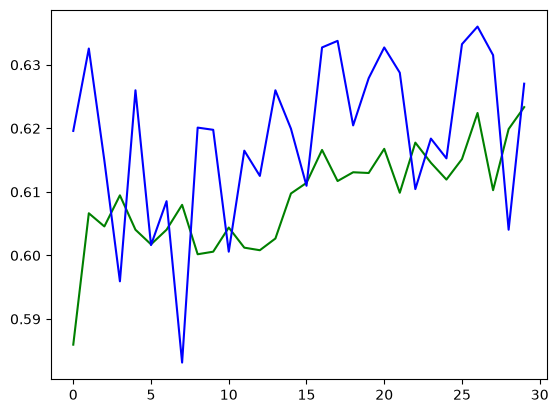

In [13]:
plt.plot(history.history['accuracy'], color='green')
plt.plot(history.history['val_accuracy'], color='blue')

In [14]:
model.save('catvsdog.h5')